In [1]:
from itertools import product
import os

import numpy as np
import scipy as sp

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import mne

import crocopy

c:\Users\willy\anaconda3\envs\crosspy_env\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [2]:
def compute_phase_difference(x, y):
    x_normed = x / np.abs(x)
    y_normed = y / np.abs(y)

    return x_normed * y_normed.conj()

In [3]:
data_path_ec = os.path.join('..', 'data', 'tutorial_data', 'sub-032311', 'sub-032311_EC.set')
data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)

data_obj_ec.set_eeg_reference(projection=True, verbose=False).apply_proj(verbose=False)
data_obj_ec_csd = mne.preprocessing.compute_current_source_density(data_obj_ec, verbose=False)

data_broadband = data_obj_ec_csd.get_data()

C:\Users\willy\AppData\Local\Temp\ipykernel_37324\2053390488.py:2: RuntimeWarning: Data file name in EEG.data (sub-010017_EC.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-032311_EC.fdt).
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)
C:\Users\willy\AppData\Local\Temp\ipykernel_37324\2053390488.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)
C:\Users\willy\AppData\Local\Temp\ipykernel_37324\2053390488.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)


In [4]:
central_frequency = 10.0
data_filt = crocopy.preprocessing.signal.filter_data(data_broadband, sfreq=data_obj_ec.info['sfreq'], frequency=central_frequency, omega=5.0, n_jobs='cuda').get()

In neuroscience, the functional connectivity describes how similar is dynamics of signals from two (or more) brain areas. In the analysis of oscillations, it could be defined as phase synchronization and operationalized with Phase Locking Value (PLV).

PLV answers on a question 'how stable is phase difference between two signals' (note that at this moment we dont take into account the actual phase difference, only that it is stable!). 

To compute PLV for two signals \(x(t)\) and \(y(t)\), extract their instantaneous phases $\phi_x(t)$ and $\phi_y(t)$ (e.g., via Hilbert transform or a complex wavelet).
For \(N\) time samples compute sample-by-sample phase difference

$\Delta\phi_n = \phi_x(n) - \phi_y(n), \quad n=1,\dots,N.$

The PLV is defined as:

$
\mathrm{PLV} = \left| \frac{1}{N}\sum_{n=1}^{N} e^{\,i\Delta\phi_n} \right|.
$

However, those computations require several expensive operations (exponent in complex domain and phase extraction). Since narrow-band filtering allows to obtain analytical signal (Complex Wavelet Transform returns it naturally or one can apply Hilbert transform after regular filters), one can compute phase-differences from it.

Let $z_x[n]$ and $z_y[n]$ be the complex analytic signals

Normalize to unit magnitude:
$
u_x[n] = \frac{z_x[n]}{|z_x[n]|}, \qquad
u_y[n] = \frac{z_y[n]}{|z_y[n]|}.
$

Then the Phase Locking Value (PLV) is:

$
\mathrm{PLV} = \left| \frac{1}{N}\sum_{n=1}^{N} u_x[n]\;u_y[n]^* \right|.
$

So essentially its $cPLV = \frac{1}{N} \sum x_n * y^*_n$ where $y_n^*$ is conjugate of $y_n$ and $x_n$, $y_n$ are unit-normed versions of complex signals x, y.

Lets compute it for some EEG data and check how does it look.

In [5]:
cplv_values = crocopy.observables.connectivity.synchrony.compute_cplv(data_filt)

plv_values = np.abs(cplv_values)

np.fill_diagonal(plv_values, 0.0)

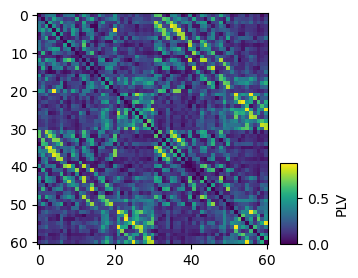

In [6]:
fig, ax = plt.subplots(figsize=(3,3))

cax = ax.inset_axes((1.05, 0.0, 0.075, 0.35))

imh = ax.imshow(plv_values)

fig.colorbar(imh, cax=cax, label='PLV')

The non-invasive electrophysiological recordings such as EEG / MEG are highly susceptible to volume conduction and field spread, which can induce spurious zero-lag coupling between electrodes. Because zero-lag coupling has phase difference of zero (and imaginary component of it is also zero), it is preferable to use connectivity metrics that down-weight or exclude instantaneous interactions, such as measures based on the imaginary component. In case of cPLV, one can use imaginary part of it (iPLV) rather then |cPLV|.

Lets have a look on it.

In [7]:
iplv_values = cplv_values.imag
np.fill_diagonal(iplv_values, 0.0)

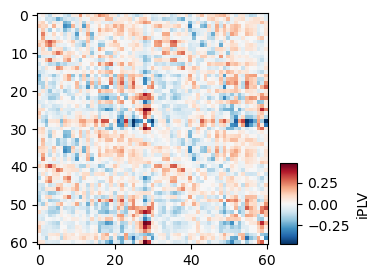

In [8]:
fig, ax = plt.subplots(figsize=(3,3))

cax = ax.inset_axes((1.05, 0.0, 0.075, 0.35))

imh = ax.imshow(iplv_values, cmap='RdBu_r')

fig.colorbar(imh, cax=cax, label='iPLV')

Note, that unlike PLV which is bounded in $[0,1]$, iPLV is a signed metric where sign of $iPLV(X,Y)$ indicates whether X preceeds or leads Y.

Lets visualize timeseries of two channels with stable phase lag between them.

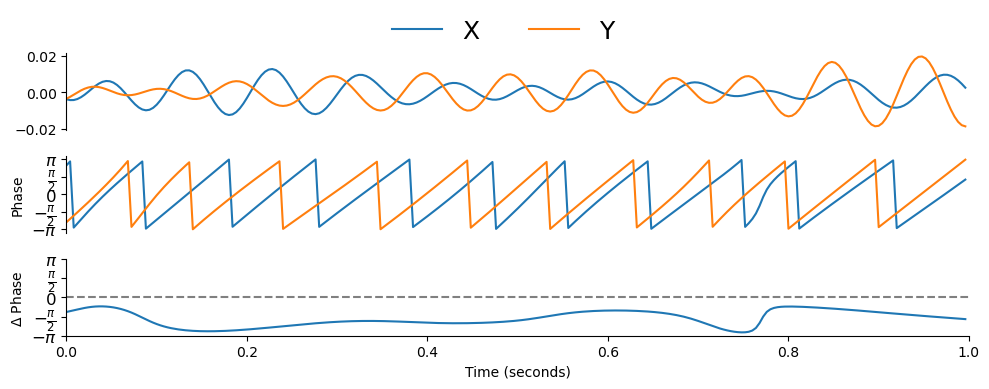

In [9]:
xy_phase_difference = compute_phase_difference(data_filt[3], data_filt[44])

t_values = np.arange(250)/data_obj_ec.info['sfreq']

fig, axes = plt.subplots(figsize=(10,4), nrows=3)

axes[0].plot(t_values, data_filt[3, 3500:3750].real, label='X')
axes[0].plot(t_values, data_filt[44, 3500:3750].real, label='Y')

axes[1].plot(t_values, np.angle(data_filt[3, 3500:3750]))
axes[1].plot(t_values, np.angle(data_filt[44, 3500:3750]))

axes[2].plot(t_values, np.angle(xy_phase_difference[3500:3750]))
axes[2].plot([0, 1], [0, 0], ls='--', color='gray')

axes[0].set_xticks([])
axes[1].set_xticks([])

ticks = np.array([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])

axes[1].set_yticks(ticks, labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'], fontsize=12)
axes[2].set_yticks(ticks, labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'], fontsize=12)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    ax.set_xlim([0,1])

axes[2].spines['bottom'].set_visible(True)

axes[0].legend(loc=(0.35, 1.0), ncols=2, fontsize=18, frameon=False)

axes[1].set_ylabel('Phase')

axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel(r'$\Delta$ Phase')

fig.tight_layout()

Next, we can have a look on distribution of phase difference between X and Y, visualized both as regular histogram and on polar plot.

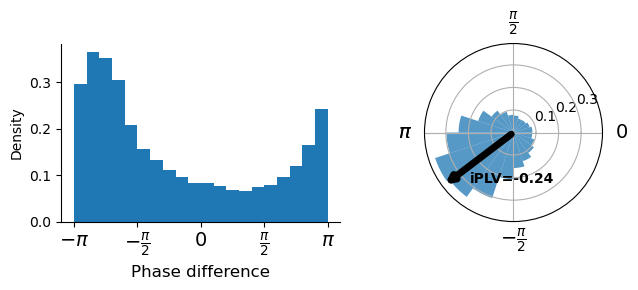

In [11]:
xy_mean_pd = np.mean(xy_phase_difference)
angles = np.angle(xy_phase_difference)

fig = plt.figure(figsize=(7, 3))

axes = [fig.add_subplot(1, 2, 1), fig.add_subplot(1, 2, 2, projection='polar')]

axes[0].hist(angles, bins=20, density=True)

ticks = np.array([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])

axes[0].set_xticks(ticks, labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'], fontsize=14)
axes[0].set_ylabel('Density')

counts, edges = np.histogram(angles, bins=20, range=(-np.pi, np.pi), density=True)
centers =(edges[:-1] + edges[1:])/2
width = edges[1] - edges[0]

axes[1].bar(centers, counts, width=width, align='center', alpha=0.75)

axes[1].set_thetagrids(np.degrees(ticks % (2*np.pi)), labels=[r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$'], fontsize=14)

th = np.angle(xy_mean_pd)
rr = np.abs(xy_mean_pd)
axes[1].annotate('', xy=(th, rr), xytext=(th, 0), arrowprops=dict(arrowstyle='->', lw=5))

axes[1].text(th + 0.2, rr*3/4, f'iPLV={xy_mean_pd.imag:.2f}', fontweight='black')


axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlabel('Phase difference', fontsize=12)

axes[1].set_ylim((0, rr))

fig.tight_layout()

plt.show()


Note that those two signals have systematic __negative__ phase difference and quite high iPLV=-0.32. 

iPLV treats all imaginary components equally, while small phase lags around zero could be noisy. To improve the phase synchronization estimation, the weighted Phase Lag Index (wPLI) down-weights near–zero-lag phase differences, so its more robust to volume conduction / field spread in comparison to iPLV.

Lets compute and have a look on it.

In [12]:
wpli_values = crocopy.observables.connectivity.synchrony.compute_wpli(data_filt)

np.fill_diagonal(wpli_values, 0.0)

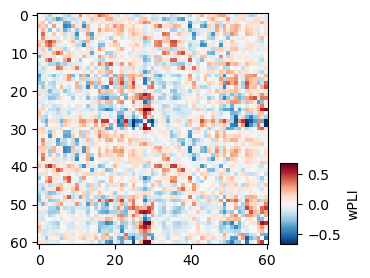

In [13]:
fig, ax = plt.subplots(figsize=(3,3))

cax = ax.inset_axes((1.05, 0.0, 0.075, 0.35))

imh = ax.imshow(wpli_values, cmap='RdBu_r')

fig.colorbar(imh, cax=cax, label='wPLI')

Note that both wPLI and iPLV are signed because they are based on relative phase difference. Typically, only the absolute value of these metrics is analyzed but in some advanced cases (e.g analysis of time-resolved phase synchronization) the sign is preserved.

We have been looking on phase synchronization observables where a signal amplitude is disregarded. However, the oscillation envelope is a proxy for local (within brain-area) synchronization and the correlation of amplitudes convey different information and reflect distinct neurophysological processes in comparison to phase synchronization.

In the basic form the amplitude correlations are just a Pearson correlation coefficient of narrow-band envelopes. However, it suffers the same problem of volume conduction and to avoid it the orthogonalized Correlation Coefficient (oCC) was introduced. oCC between analytical signals X,Y introduces the orthogonalization step when phase difference between X,Y is compensated ($Y_{\perp X}$) and the correlation is computed between envelopes of $X$ and $Y_{\perp X}$

$
y_{\perp x}(t)= i\,x_n(t)\,\mathrm{imag}\!\left( y(t)\,x_n^*(t)\right)
$

where $x_n(t)$ is unit-normed X at time $t$.


In [14]:
occ_values = crocopy.observables.connectivity.amplitude_correlations.compute_occ(data_filt)

np.fill_diagonal(occ_values, 0.0)

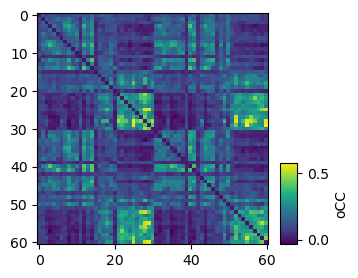

In [15]:
fig, ax = plt.subplots(figsize=(3,3))

cax = ax.inset_axes((1.05, 0.0, 0.075, 0.35))

imh = ax.imshow(occ_values)

fig.colorbar(imh, cax=cax, label='oCC')

oCC is a signed metric but negative values are typically very small and |oCC| is analyzed. 

Lets check how those observables relate to each other.

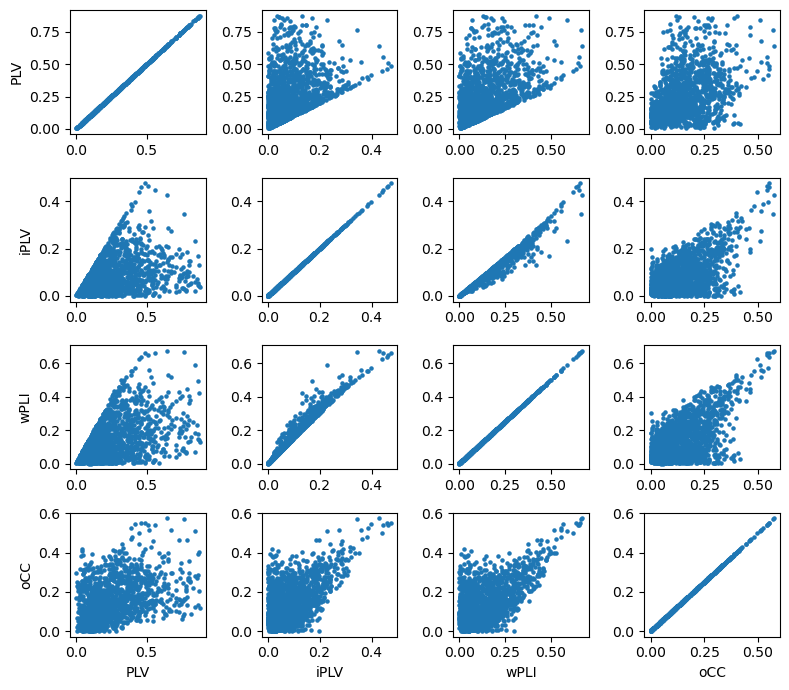

In [16]:
fc_triu_indices = np.triu_indices_from(wpli_values, 1)

fig, axes = plt.subplots(figsize=(8,7), ncols=4, nrows=4)

observable_names = ['PLV', 'iPLV', 'wPLI', 'oCC']
observable_arrays = [plv_values, np.abs(iplv_values), np.abs(wpli_values), np.abs(occ_values)]

for i, j in product(range(4), range(4)):
    axes[j,i].scatter(observable_arrays[i][fc_triu_indices], observable_arrays[j][fc_triu_indices], s=5)
    axes[j,i].set_xlabel(observable_names[i])
    axes[j,i].set_ylabel(observable_names[j])

    if (j != len(observable_names) - 1):
        axes[j,i].set_xlabel('')
    
    if (i > 0):
        axes[j,i].set_ylabel('')

fig.tight_layout()

The PLV often over-estimates the level of phase synchronization between two regions, while iPLV and wPLI have very high correlation. oCC is also moderately correlated with iPLV and wPLI.

Next, lets have a closer look on those methods when we can construct data with desired properties such as phase shift, phase or amplitude mixings.

In [ ]:
def mix_two_filtered_signals(c_A, c_theta, m, phase_shift, N=500000):
    '''
    Constructing two filtered mixed signals as described by Palva 2018 NeuroImage.
    INPUT:
        c_A:            Amplitude mixing parameter
        c_theta:        Phase mixing parameter
        m:              Signals inter-mixing parameter
        phase_shift:    Controlling mean phase difference across x and y signals
        N:              Number of samples
    OUTPUT:
        Numpy array of signals x and y
    '''
    
    #helper method to filter the timeseries
    def _filter_wrapper(timeseries):
        return crocopy.preprocessing.signal.filter_data(timeseries.reshape(1, *timeseries.shape), sfreq=250, frequency=10, omega=5.0, n_jobs=1).squeeze()
    
    #generating random values for further manipulation
    noise_timeseries = np.random.normal(size=(4, N))

    #generating amplitudes for signal x and signal y
    A_x = np.abs(_filter_wrapper(noise_timeseries[0] + c_A*noise_timeseries[1]))
    A_y = np.abs(_filter_wrapper(noise_timeseries[1] + c_A*noise_timeseries[0]))

    #generating phases for signal x and signal y
    phase_x = np.angle(_filter_wrapper(noise_timeseries[2] + c_theta*noise_timeseries[3]))
    phase_y = np.angle(_filter_wrapper(noise_timeseries[3] + c_theta*noise_timeseries[2]))

    #assembling complex-valued mixed time series x and y
    x = A_x*np.exp(1j*phase_x) + m*A_y * np.exp(1j*(phase_y + phase_shift))
    y = A_y*np.exp(1j*(phase_y + phase_shift)) + m*A_x * np.exp(1j*phase_x)
    
    return np.array([x, y])

###  Phase mixing parameter affect on connectivity

Folliwing (Palva et. al. 2018), lets check the effect of phase mixing and phase shift on our four connectivity observables. 

An oscillatory complex signal could be generated by applying CWT to white noise. Two signals constructed from different noise realizations are unrelated and we can mix them controlling the linear coupling strength or phase lag between them:

$
A_x=\left|CWT(n_1+c_A*n_2)\right|,\qquad
A_y=\left|CWT(n_2+c_A*n_1)\right|
$

$
\theta_x=\arg(CWT(n_3 + c_\theta*n_4)),\qquad
\theta_y=\arg(CWT(n_4 + c_\theta*n_3))
$


$
x(t)=A_x*e^{i\theta_x} + m\,A_y(t)e^{i(\theta_y+\phi_{xy})}
$

$
y(t)=A_y*e^{i(\theta_y+\phi_{xy})} + m\,A_xe^{i\theta_x}
$

where $n_{1,2,3,4}$ are different realizations of white noise, $c_A$ is amplitude mixing strength, $c_\theta$ is phase mixing strength and $m$ is linear mixing strength.

In [ ]:
import xarray as xr

def check_parameters_combo(A, m, c_theta, phase_shift, n_iters=10):
    plv_result = np.zeros(n_iters)
    iplv_result = np.zeros(n_iters)
    wpli_result = np.zeros(n_iters)
    occ_result = np.zeros(n_iters)

    for i in range(n_iters):
        signals_mixed = mix_two_filtered_signals(A, c_theta, m, phase_shift, N=50000)

        cplv_vals = crocopy.observables.connectivity.synchrony.compute_cplv(signals_mixed, zero_diag=True)

        wpli_vals = np.abs(crocopy.observables.connectivity.synchrony.compute_wpli(signals_mixed))
        plv_vals = np.abs(cplv_vals)
        iplv_vals = np.abs(np.imag(cplv_vals))
        occ_vals = crocopy.observables.connectivity.amplitude_correlations.compute_occ(signals_mixed)

        plv_result[i] = plv_vals[0,1]
        iplv_result[i] = iplv_vals[0,1]
        wpli_result[i] = wpli_vals[0,1]
        occ_result[i] = occ_vals[0,1]
    
    return plv_result, iplv_result, wpli_result, occ_result


def compute_synchrony_as_mixing(params_dict, n_iters=10):
    keys = list(params_dict.keys())
    grids = [params_dict[k] for k in keys]
    params_shape = [len(parameter_values) for parameter_values in params_dict.values()] + [4, n_iters]

    # foo must be callable like foo(a=..., b=..., c=...)
    result_scattered = [check_parameters_combo(**dict(zip(keys, combo)), n_iters=n_iters) for combo in product(*grids)]

    result_gathered = np.asarray(result_scattered).reshape(params_shape)

    plv_result, iplv_result, wpli_result, occ_result = map(lambda arr: xr.DataArray(arr, dims=keys + ['samples']).squeeze(), np.moveaxis(result_gathered, len(keys), 0))

    return plv_result, iplv_result, wpli_result, occ_result


In [172]:
params_grid = {'A': [1],
               'm': np.linspace(0, 0.6, 7),
               'c_theta': np.linspace(0, 1, 50),
               'phase_shift': [1]}

plv_result, iplv_result, wpli_result, occ_result = compute_synchrony_as_mixing(params_grid)

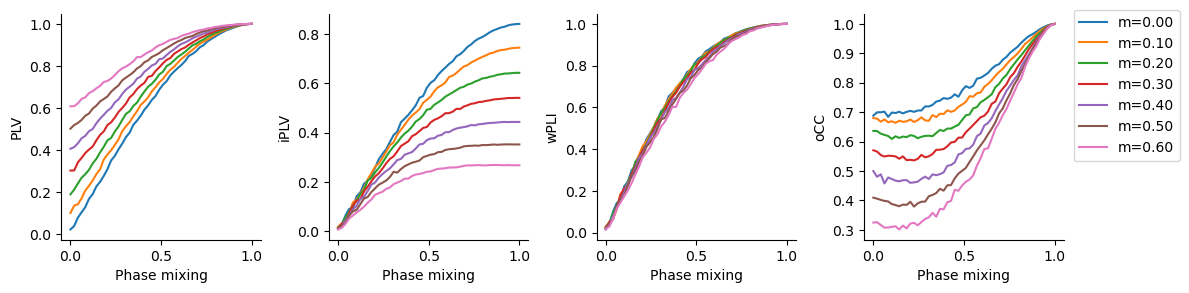

In [173]:
labels = [f'm={m_value:.2f}' for m_value in params_grid['m']]

fig, axes = plt.subplots(figsize=(12,3), ncols=4)

_ = axes[0].plot(params_grid['c_theta'], plv_result.mean(dim='samples').T)
_ = axes[1].plot(params_grid['c_theta'], iplv_result.mean(dim='samples').T)
_ = axes[2].plot(params_grid['c_theta'], wpli_result.mean(dim='samples').T)
_ = axes[3].plot(params_grid['c_theta'], occ_result.mean(dim='samples').T)

for ax, ylabel in zip(axes, ['PLV', 'iPLV', 'wPLI', 'oCC']):
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Phase mixing')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[~0].legend(labels, loc=(1.05, 0.35))

fig.tight_layout()

In [174]:
params_grid_phase_shift = {'A': [1],
                           'm': np.linspace(0, 0.6, 7),
                           'c_theta': [0.4],
                           'phase_shift': np.linspace(-np.pi, np.pi, 50)}

plv_result_shift, iplv_result_shift, wpli_result_shift, occ_result_shift = compute_synchrony_as_mixing(params_grid_phase_shift)

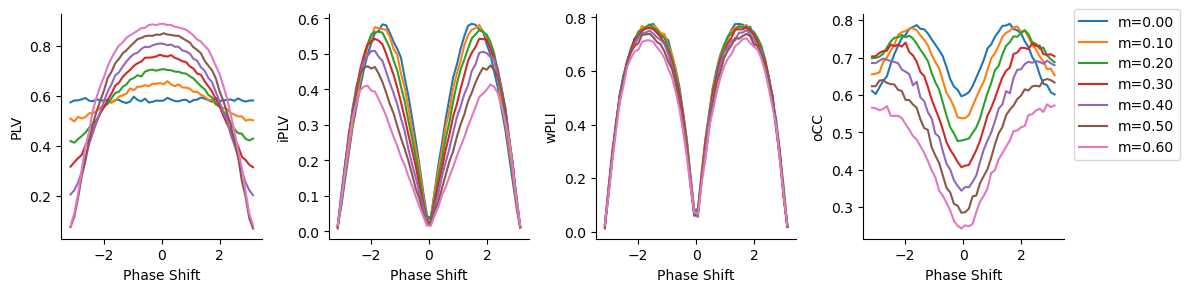

In [180]:
fig, axes = plt.subplots(figsize=(12,3), ncols=4)

_ = axes[0].plot(params_grid_phase_shift['phase_shift'], plv_result_shift.mean(dim='samples').T)
_ = axes[1].plot(params_grid_phase_shift['phase_shift'], iplv_result_shift.mean(dim='samples').T)
_ = axes[2].plot(params_grid_phase_shift['phase_shift'], wpli_result_shift.mean(dim='samples').T)
_ = axes[3].plot(params_grid_phase_shift['phase_shift'], occ_result_shift.mean(dim='samples').T)

for ax, ylabel in zip(axes, ['PLV', 'iPLV', 'wPLI', 'oCC']):
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Phase Shift')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[~0].legend(labels, loc=(1.05, 0.35))

fig.tight_layout()